In [1]:
import numpy as np
from PIL import Image, ImageOps
import os
import pandas as pd
from sklearn.model_selection import train_test_split

In [2]:
def convert_image_to_grayscale_with_padding(image_path, target_width=None, target_height=None):
    """
    Converts a single .jpg image to grayscale and optionally pads it to the target dimensions.

    Args:
        image_path (str): Path to the input .jpg image.
        target_width (int, optional): Target width for padding. If None, keeps the original width.
        target_height (int, optional): Target height for padding. If None, keeps the original height.

    Returns:
        np.ndarray: Grayscale image as a numpy array, with optional padding applied.
    """
    # Open the image
    with Image.open(image_path) as img:
        # Convert to grayscale
        grayscale_img = img.convert('L')
        
        # If target dimensions are provided, pad the image
        if target_width and target_height:
            padded_img = ImageOps.pad(grayscale_img, (target_width, target_height), color=0)
        else:
            padded_img = grayscale_img
        
        # Convert the image to a numpy array
        grayscale_array = np.array(padded_img)

    return grayscale_array

In [3]:
# reduce each image to be a 400x400 square that only captures the relevant area of the image
raw_folder = "data/images"
cropped_folder = "data/images_cropped"

os.makedirs(cropped_folder, exist_ok=True)

for filename in os.listdir(raw_folder):
    if filename.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp")):
        input_path = os.path.join(raw_folder, filename)
        output_path = os.path.join(cropped_folder, filename)

        img = Image.open(input_path)
        cropped = img.crop((440, 160, 840, 560))
        cropped.save(output_path)
        print(f"Saved: {filename}")

Saved: 88.png
Saved: 162.png
Saved: 77.png
Saved: 63.png
Saved: 62.png
Saved: 76.png
Saved: 163.png
Saved: 89.png
Saved: 149.png
Saved: 161.png
Saved: 175.png
Saved: 60.png
Saved: 74.png
Saved: 48.png
Saved: 49.png
Saved: 75.png
Saved: 61.png
Saved: 174.png
Saved: 160.png
Saved: 148.png
Saved: 164.png
Saved: 170.png
Saved: 158.png
Saved: 59.png
Saved: 65.png
Saved: 71.png
Saved: 70.png
Saved: 64.png
Saved: 58.png
Saved: 159.png
Saved: 171.png
Saved: 165.png
Saved: 173.png
Saved: 167.png
Saved: 99.png
Saved: 8.png
Saved: 72.png
Saved: 66.png
Saved: 67.png
Saved: 73.png
Saved: 9.png
Saved: 166.png
Saved: 98.png
Saved: 172.png
Saved: 129.png
Saved: 115.png
Saved: 101.png
Saved: 14.png
Saved: 28.png
Saved: 29.png
Saved: 15.png
Saved: 100.png
Saved: 114.png
Saved: 128.png
Saved: 102.png
Saved: 116.png
Saved: 17.png
Saved: 16.png
Saved: 117.png
Saved: 103.png
Saved: 107.png
Saved: 113.png
Saved: 12.png
Saved: 13.png
Saved: 112.png
Saved: 106.png
Saved: 110.png
Saved: 104.png
Saved: 138.png
S

In [4]:
images = []

for index, filename in enumerate(os.listdir(cropped_folder)):
    images.append(convert_image_to_grayscale_with_padding(f'{cropped_folder}/{index + 1}.png'))
    
images = np.array(images)
images.shape

(175, 400, 400)

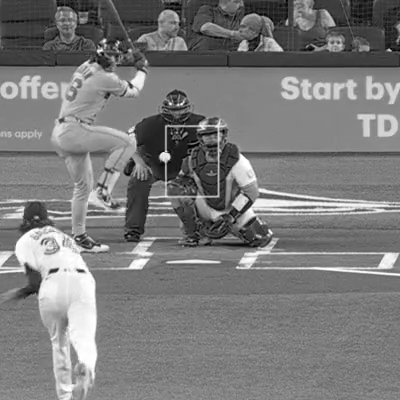

In [5]:
### EXAMPLE GREYSCALE IMAGE FOR POSTER/REPORT PURPOSES
with Image.open("data/images_cropped/1.png") as img:
	grayscale_img = img.convert("L")

grayscale_img

In [6]:
num_data = pd.read_csv('data/pitches/gausman_pitches.csv')
num_data = pd.get_dummies(num_data, columns=['PitchType'], dtype=int)
num_data['Swing'] = num_data['Swing'].map({'Y': 1, 'N': 0})
num_data.head()

,Zone,Swing,PitchType_FF,PitchType_SL,PitchType_SP
0,14,0,1,0,0
1,6,0,1,0,0
2,12,1,1,0,0
3,12,0,0,1,0
4,3,1,1,0,0


In [7]:
img_rows, img_cols = 400, 400

In [8]:
y = np.array(num_data['Swing'])

In [9]:
x_train_img, x_test_img, y_train, y_test = train_test_split(
    images, y, test_size=0.25, random_state=7
)
x_train_num, x_test_num, y_train, y_test = train_test_split(
    num_data, y, test_size=0.25, random_state=7
)

In [10]:
print(x_train_img)
x_train_num

[[[ 59  60  66 ... 153 130 121]
  [ 55  55  57 ... 158 146 132]
  [ 44  45  52 ... 163 168 180]
  ...
  [130 132 130 ... 123 124 136]
  [130 133 133 ... 120 117 128]
  [118 131 140 ... 120 120 124]]

 [[ 62  34  43 ... 106 130 139]
  [ 47  26  43 ... 105 128 136]
  [ 42  37  52 ... 102 121 127]
  ...
  [117 123 125 ... 115 112 117]
  [124 125 127 ... 121 116 113]
  [131 128 127 ... 124 120 116]]

 [[ 51  91  93 ...  69  69  67]
  [ 67 105  98 ...  62  62  62]
  [ 85 108  96 ...  67  67  64]
  ...
  [136 137 138 ... 142 134 130]
  [141 143 144 ... 137 129 122]
  [150 157 149 ... 135 133 133]]

 ...

 [[ 72  56  48 ... 138 121 105]
  [ 86  83  79 ... 125 111 107]
  [ 95  84  78 ... 113 103 104]
  ...
  [136 136 136 ... 127 134 127]
  [134 133 133 ... 119 125 130]
  [137 134 132 ... 127 125 127]]

 [[ 56  45  44 ... 160 157 146]
  [ 55  50  51 ... 175 192 191]
  [ 57  58  58 ... 192 200 208]
  ...
  [133 131 131 ... 113 105 116]
  [141 134 134 ... 108 104 104]
  [134 135 142 ... 129 135 1

,Zone,Swing,PitchType_FF,PitchType_SL,PitchType_SP
37,12,0,0,0,1
28,1,1,1,0,0
65,3,1,1,0,0
138,5,1,1,0,0
66,14,1,0,0,1
...,...,...,...,...,...
92,14,0,1,0,0
103,9,0,0,0,1
151,4,1,1,0,0
67,8,1,0,0,1


In [11]:
x_train_num = x_train_num.drop(columns=['Swing']).astype('float32')
x_test_num = x_test_num.drop(columns=['Swing']).astype('float32')

# normalize
x_train_img = np.expand_dims(x_train_img, axis=-1) / 255.0
x_test_img = np.expand_dims(x_test_img, axis=-1) / 255.0

num_features = x_train_num.shape[1]

In [12]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Concatenate, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

#CNN
# 1 channel for grayscale
image_input = Input(shape=(img_rows, img_cols, 1), name="image_input")

x = Conv2D(32, kernel_size=(3, 3), activation='relu')(image_input)
x = MaxPooling2D(pool_size=(2, 2))(x)
x = Conv2D(64, kernel_size=(3, 3), activation='relu')(x)
x = MaxPooling2D(pool_size=(2, 2))(x)
x = Conv2D(64, kernel_size=(3, 3), activation='relu')(x)
x = MaxPooling2D(pool_size=(2, 2))(x)

# flatten
cnn_out = Flatten()(x)

pitch_input = Input(shape=(num_features,), name="pitch_input")

# layer for the pitches data
y = Dense(16, activation='relu')(pitch_input)

# combine the flattened image vector and the processed pitch vector
combined = Concatenate()([cnn_out, y])

# final dense layers to predict the swing
z = Dense(128, activation='relu')(combined)
z = Dropout(0.5)(z) # helps prevent overfitting since we have limited data
final_output = Dense(1, activation='sigmoid', name="swing_output")(z)

model = Model(inputs=[image_input, pitch_input], outputs=final_output)

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

2026-04-15 21:56:09.670729: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 400, 400,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 398, 398,  │        320 │ image_input[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 199, 199,  │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 197, 197,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 98, 98,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 96, 96,    │     36,928 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 48, 48,    │          0 │ conv2d_2[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pitch_input         │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 147456)    │          0 │ max_pooling2d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 16)        │         80 │ pitch_input[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 147472)    │          0 │ flatten[0][0],    │
│ (Concatenate)       │                   │            │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │ 18,876,544 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ swing_output        │ (None, 1)         │        129 │ dropout[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 18,932,497 (72.22 MB)

 Trainable params: 18,932,497 (72.22 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss',
                           patience=5, # if the loss doesn't get better for 5 epohs stop traingin
                           restore_best_weights=True, # uses weights before the 5 epoch stall
                           verbose=1)

history = model.fit(
    x=[x_train_img, x_train_num],
    y=y_train,
    validation_data=([x_test_img, x_test_num], y_test),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 15s 3s/step - accuracy: 0.6489 - loss: 0.6277 - val_accuracy: 0.4091 - val_loss: 0.7398
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 14s 3s/step - accuracy: 0.5802 - loss: 0.7514 - val_accuracy: 0.6364 - val_loss: 0.6173
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 13s 3s/step - accuracy: 0.5344 - loss: 0.6691 - val_accuracy: 0.6591 - val_loss: 0.6138
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 14s 3s/step - accuracy: 0.6107 - loss: 0.6732 - val_accuracy: 0.5909 - val_loss: 0.6491
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.6183 - loss: 0.6509 - val_accuracy: 0.8182 - val_loss: 0.6298
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 16s 3s/step - accuracy: 0.6489 - loss: 0.6274 - val_accuracy: 0.7727 - val_loss: 0.6198
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 14s 3s/step - accuracy: 0.6641 - loss: 0.6198 - val_accuracy: 0.4545 - val_loss: 0.7762
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 15s 3s/step - accuracy: 0.6641 - loss: 0.6114 - val_accuracy: 0.7500 - val_loss: 0.6090


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step


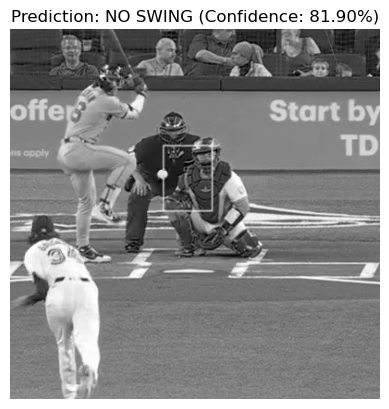

In [29]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

def test_single_uploaded_pitch(model, img_path, pitch_features_df, pitch_index):
    img = Image.open(img_path)

    # Convert to grayscale
    grayscale_img = img.convert('L')
    img_array = np.array(grayscale_img)

    # Normalize to [0,1] and expand dims to (1, 400, 400, 1)
    norm_array = img_array / 255.0
    img_batch = np.expand_dims(norm_array, axis=0)
    img_batch = np.expand_dims(img_batch, axis=-1)

    # get specific row for this case (first png)
    pitch_features = pitch_features_df.drop(columns=['Swing']).iloc[pitch_index].values.astype('float32')
    pitch_batch = np.expand_dims(pitch_features, axis=0) # Make it (1, num_features)

    # example prediction
    prediction = model.predict([img_batch, pitch_batch])[0][0]

    # swing ouptut
    label = "SWING" if prediction >= 0.5 else "NO SWING"
    confidence = prediction if prediction >= 0.5 else 1 - prediction

    # plot of example
    plt.imshow(img_array, cmap='gray', vmin=0, vmax=255)
    plt.title(f"Prediction: {label} (Confidence: {confidence:.2%})")
    plt.axis('off')
    plt.show()

test_single_uploaded_pitch(model, 'data/images_cropped/1.png', num_data, pitch_index=0) # pitch index 0 for first entry

In [30]:
y_pred_probs = model.predict([x_test_img, x_test_num]).ravel()

# Convert probabilities to binary predictions (0 or 1) using a 0.5 threshold
y_pred_binary = (y_pred_probs > 0.5).astype("int32")


2/2 ━━━━━━━━━━━━━━━━━━━━ 18s 4s/step
[0.34270617 0.41602507 0.26050946 0.34013295 0.585044   0.51495165
 0.38485113 0.33750674 0.37620497 0.27501994 0.3272575  0.2591835
 0.6121152  0.22820455 0.38673005 0.34038803 0.4448323  0.26873794
 0.5433565  0.33436346 0.4456988  0.26698846 0.45539188 0.3649017
 0.475972   0.5213437  0.3073773  0.36678764 0.26710415 0.42300838
 0.40806738 0.48111486 0.26550668 0.44256923 0.51267105 0.26200387
 0.45515296 0.40574792 0.29514548 0.4420929  0.25933212 0.44172895
 0.64125055 0.30656222]


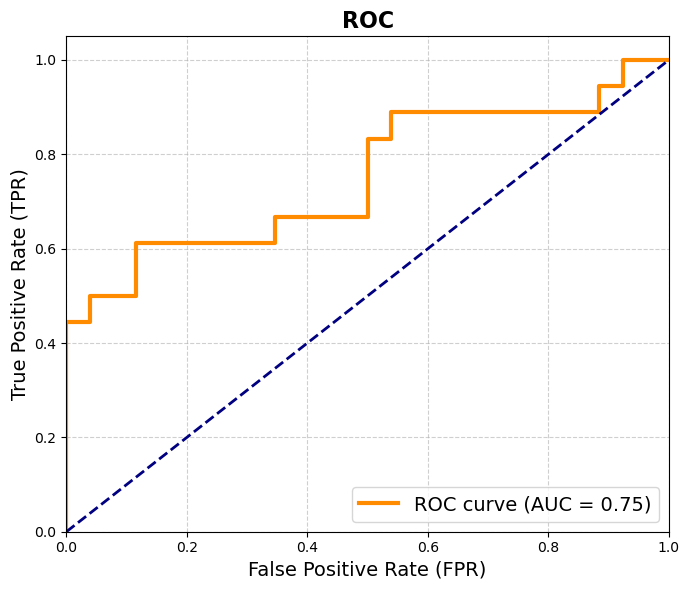

In [34]:
from sklearn.metrics import confusion_matrix, roc_curve, auc
fpr, tpr, thresholds = roc_curve(y_test, y_pred_probs)

# Calculate the Area Under the Curve (AUC)
roc_auc = auc(fpr, tpr)

# Create a figure for the ROC Curve
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkorange', lw=3, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # The baseline 50/50 guessing line

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)', fontsize=14)
plt.ylabel('True Positive Rate (TPR)', fontsize=14)
plt.title('ROC', fontsize=16, fontweight='bold')
plt.legend(loc="lower right", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()

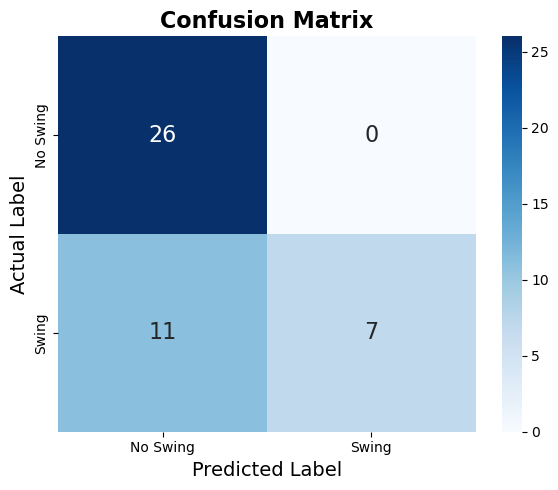

In [33]:
import seaborn as sns
# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred_binary)

# Create a figure for the Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Swing', 'Swing'],
            yticklabels=['No Swing', 'Swing'],
            annot_kws={"size": 16}) # Large text for readability

plt.title('Confusion Matrix', fontsize=16, fontweight='bold')
plt.ylabel('Actual Label', fontsize=14)
plt.xlabel('Predicted Label', fontsize=14)
plt.tight_layout()

plt.show()